# Loan Approval Prediction Decision Tree Classifier

## 1. Imports & Setup

In [1]:
import os
import pickle
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


## 2. Load the Data

In [2]:
df = pd.read_csv("loan_data.csv")
print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (45000, 5)


,Age,Income,LoanAmount,CreditScore,Approved
0,22,71948,35000,561,1
1,21,12282,1000,504,0
2,25,12438,5500,635,1
3,23,79753,35000,675,1
4,24,66135,35000,586,1


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Age          45000 non-null  int64
 1   Income       45000 non-null  int64
 2   LoanAmount   45000 non-null  int64
 3   CreditScore  45000 non-null  int64
 4   Approved     45000 non-null  int64
dtypes: int64(5)
memory usage: 1.7 MB


,Age,Income,LoanAmount,CreditScore,Approved
count,"45,000.00","45,000.00","45,000.00","45,000.00","45,000.00"
mean,27.76,"80,319.05","9,583.16",632.61,0.22
std,6.05,"80,422.50","6,314.89",50.44,0.42
min,20.00,"8,000.00",500.00,390.00,0.00
25%,24.00,"47,204.00","5,000.00",601.00,0.00
50%,26.00,"67,048.00","8,000.00",640.00,0.00
75%,30.00,"95,789.25","12,237.25",670.00,0.00
max,144.00,"7,200,766.00","35,000.00",850.00,1.00


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget balance (Approved):")
counts = df["Approved"].value_counts()
print(counts)
print(f"\nApproval rate: {df['Approved'].mean():.1%}  "
      f"-> the classes are IMBALANCED ({counts[0]:,} rejected vs {counts[1]:,} approved).")

Missing values per column:
Age            0
Income         0
LoanAmount     0
CreditScore    0
Approved       0
dtype: int64

Duplicate rows: 1

Target balance (Approved):
Approved
0    35000
1    10000
Name: count, dtype: int64

Approval rate: 22.2%  -> the classes are IMBALANCED (35,000 rejected vs 10,000 approved).


### 3.1 Spotting data-quality problems

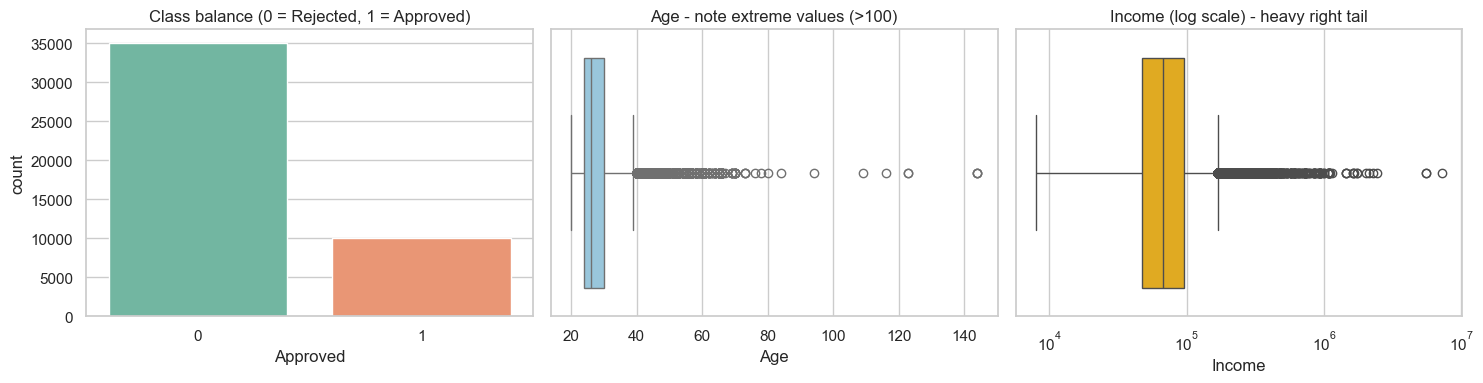

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x="Approved", data=df, ax=axes[0], hue="Approved", palette="Set2", legend=False)
axes[0].set_title("Class balance (0 = Rejected, 1 = Approved)")

sns.boxplot(x=df["Age"], ax=axes[1], color="#8ecae6")
axes[1].set_title("Age - note extreme values (>100)")

sns.boxplot(x=df["Income"], ax=axes[2], color="#ffb703")
axes[2].set_xscale("log")
axes[2].set_title("Income (log scale) - heavy right tail")

plt.tight_layout()
plt.show()

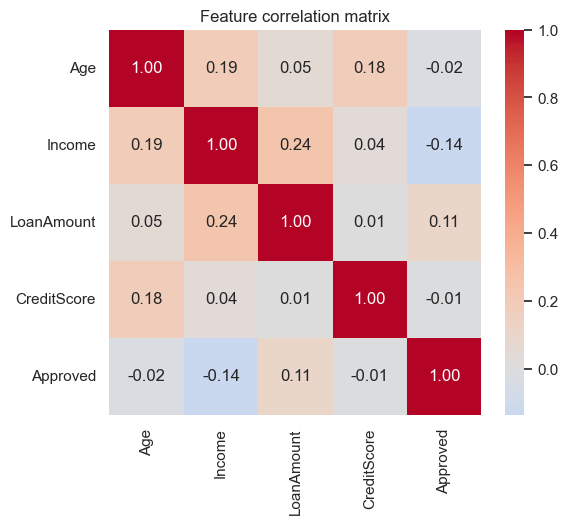

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Feature correlation matrix")
plt.show()

## 4. Data Preprocessing

### 4.1 Remove duplicates

In [7]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate row(s). Remaining rows: {len(df):,}")

Removed 1 duplicate row(s). Remaining rows: 44,999


### 4.2 Feature / target split

In [8]:
FEATURES = ["Age", "Income", "LoanAmount", "CreditScore"]
TARGET = "Approved"

X = df[FEATURES]
y = df[TARGET]
print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (44999, 4) | y shape: (44999,)


### 4.3 Stratified train / test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print("Train approval rate:", f"{y_train.mean():.1%}",
      "| Test approval rate:", f"{y_test.mean():.1%}")

Train: 35,999 rows | Test: 9,000 rows
Train approval rate: 22.2% | Test approval rate: 22.2%


### 4.4 Outlier handling winsorisation (clipping)

In [10]:
bounds = {c: (X_train[c].quantile(0.01), X_train[c].quantile(0.99)) for c in FEATURES}

def clip_features(frame, bounds):
    out = frame.copy()
    for col, (low, high) in bounds.items():
        out[col] = out[col].clip(low, high)
    return out

X_train = clip_features(X_train, bounds)
X_test = clip_features(X_test, bounds)

print("Clipping bounds (1st-99th percentile, from train set):")
for col, (low, high) in bounds.items():
    print(f"  {col:<12}: [{low:,.0f}, {high:,.0f}]")

print(f"\nAge max after clipping: {X_train['Age'].max():.0f} "
      f"(was 144 before) | Income max after clipping: {X_train['Income'].max():,.0f}")

Clipping bounds (1st-99th percentile, from train set):


  Age         : [21, 48]
  Income      : [17,833, 275,552]
  LoanAmount  : [1,171, 28,253]
  CreditScore : [497, 723]

Age max after clipping: 48 (was 144 before) | Income max after clipping: 275,552


## 5. Model Training Decision Tree

In [11]:
model = DecisionTreeClassifier(
    max_depth=7,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)
print("Model trained.")
print("Tree depth:", model.get_depth(), "| Number of leaves:", model.get_n_leaves())

Model trained.
Tree depth: 7 | Number of leaves: 98


## 6. Model Evaluation

In [12]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy :", f"{accuracy_score(y_test, y_pred):.4f}")
print("Precision:", f"{precision_score(y_test, y_pred):.4f}")
print("Recall   :", f"{recall_score(y_test, y_pred):.4f}")
print("F1-score :", f"{f1_score(y_test, y_pred):.4f}")
print("ROC-AUC  :", f"{roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=["Rejected (0)", "Approved (1)"]))

Accuracy : 0.7769
Precision: 0.4985
Recall   : 0.6475
F1-score : 0.5633
ROC-AUC  : 0.8025

Classification report:

              precision    recall  f1-score   support

Rejected (0)       0.89      0.81      0.85      7000
Approved (1)       0.50      0.65      0.56      2000

    accuracy                           0.78      9000
   macro avg       0.69      0.73      0.71      9000
weighted avg       0.80      0.78      0.79      9000



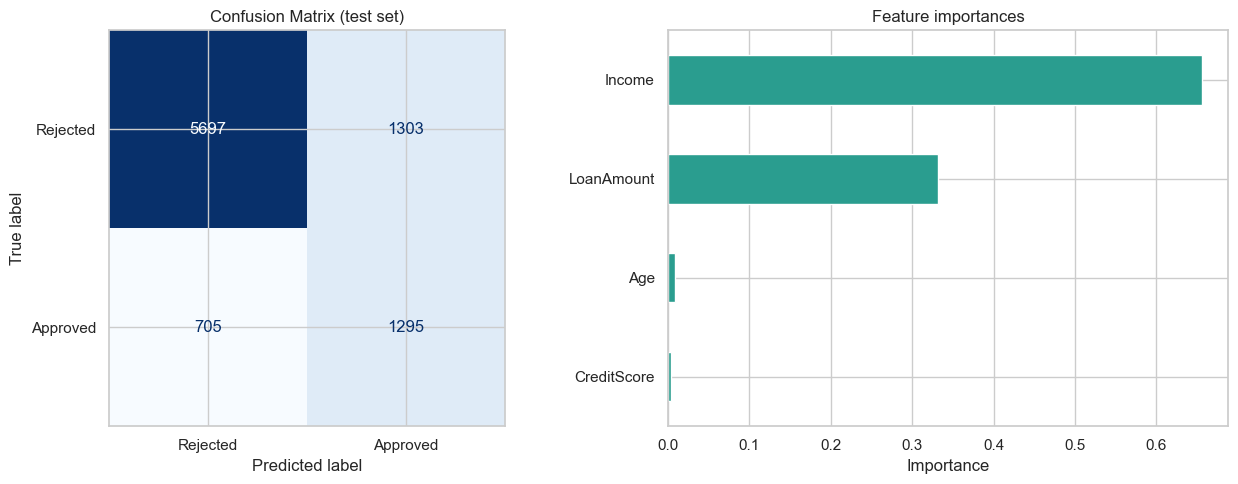

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Rejected", "Approved"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Confusion Matrix (test set)")

imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
imp.plot.barh(ax=axes[1], color="#2a9d8f")
axes[1].set_title("Feature importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

### 6.1 Visualising the top of the tree

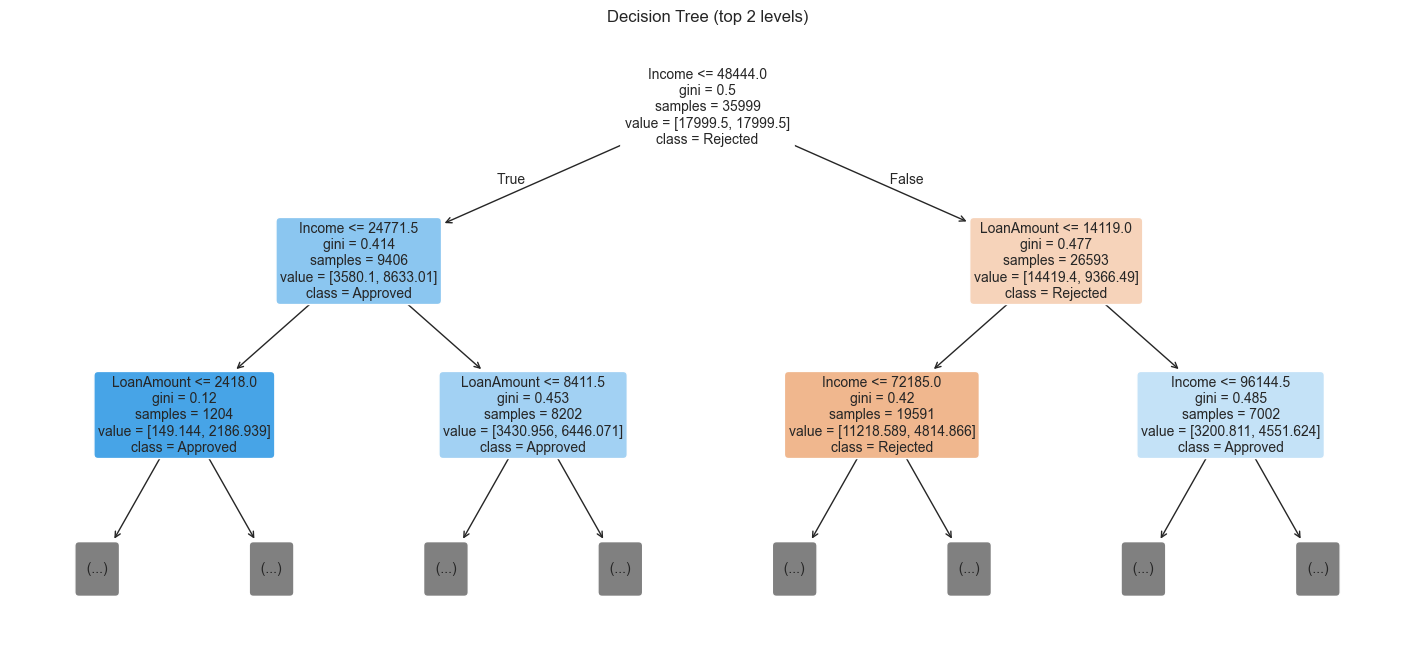

In [14]:
plt.figure(figsize=(18, 8))
plot_tree(
    model,
    max_depth=2,
    feature_names=FEATURES,
    class_names=["Rejected", "Approved"],
    filled=True, rounded=True, fontsize=10,
)
plt.title("Decision Tree (top 2 levels)")
plt.show()

## 7. Save the Model (pickle)

In [15]:
os.makedirs("model", exist_ok=True)

bundle = {
    "model": model,
    "features": FEATURES,
    "bounds": bounds,
    "metrics": {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred)),
        "recall": float(recall_score(y_test, y_pred)),
        "f1": float(f1_score(y_test, y_pred)),
        "roc_auc": float(roc_auc_score(y_test, y_proba)),
    },
    "tree_info": {
        "max_depth": model.get_params()["max_depth"],
        "depth": int(model.get_depth()),
        "nodes": int(model.tree_.node_count),
        "leaves": int(model.get_n_leaves()),
        "min_samples_leaf": model.get_params()["min_samples_leaf"],
    },
    "sklearn_version": sklearn.__version__,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
}

MODEL_PATH = os.path.join("model", "loan_model.pkl")
with open(MODEL_PATH, "wb") as fh:
    pickle.dump(bundle, fh)

print(f"Saved model bundle -> {MODEL_PATH}")
print("Bundle keys:", list(bundle.keys()))
print("Test metrics:", {k: round(v, 4) for k, v in bundle['metrics'].items()})

Saved model bundle -> model\loan_model.pkl
Bundle keys: ['model', 'features', 'bounds', 'metrics', 'tree_info', 'sklearn_version', 'trained_at']
Test metrics: {'accuracy': 0.7769, 'precision': 0.4985, 'recall': 0.6475, 'f1': 0.5633, 'roc_auc': 0.8025}


### 7.1 Reload & sanity check

In [16]:
with open(MODEL_PATH, "rb") as fh:
    reloaded = pickle.load(fh)

examples = pd.DataFrame([
    {"Age": 30, "Income": 95000, "LoanAmount": 8000,  "CreditScore": 700},
    {"Age": 22, "Income": 13000, "LoanAmount": 30000, "CreditScore": 520},
])[FEATURES]
examples_clipped = clip_features(examples, reloaded["bounds"])

preds = reloaded["model"].predict(examples_clipped)
probs = reloaded["model"].predict_proba(examples_clipped)[:, 1]
for i, row in examples.iterrows():
    verdict = "APPROVED" if preds[i] == 1 else "REJECTED"
    print(f"Applicant {i+1}: {row.to_dict()} -> {verdict} (P(approve)={probs[i]:.2f})")

Applicant 1: {'Age': 30, 'Income': 95000, 'LoanAmount': 8000, 'CreditScore': 700} -> REJECTED (P(approve)=0.49)
Applicant 2: {'Age': 22, 'Income': 13000, 'LoanAmount': 30000, 'CreditScore': 520} -> APPROVED (P(approve)=1.00)


## 8. Deploying the Model